<img src="images/banner.png" style="width: 100%;">

In [1]:
import numpy as np
import pandas as pd

# Principal Component Analysis

*References*

[1] C. Shalizi, Statistics 36-350 lecture notes, http://www.stat.cmu.edu/~cshalizi/350/lectures/10/lecture-10.pdf
[2] C. Aggarwal, Data Mining: The Textbook, Chapter 2.

In [2]:
# !conda install nltk -y # You might need to install nltk for the text preprocessing pipeline

Adapted from notebooks of **Prof Christian Alis**, revised and edited by **Leodegario Lorenzo II**

## 1 Introduction

In [3]:
import numpy as np
import matplotlib.pyplot as plt

A benefit of the techniques that we have discussed so far is that we are able to work with a very large number of dimensions simultaneously which is something that is not humanly possible. However, in general, we want to work with as few dimensions as possible. Let's look at one reason why is that so.


Consider a unit hypercube of dimensionality $d$ fully located in the nonnegative quadrant with one corner at the origin. We then take the $L_2$-norm distance of random points in the cube to the origin. We define contrast as the ratio of the variation of the distances to the mean distance. The plot of the contrast for different values of $d$ is shown below.

<img src="images/contrast.png" />

In [4]:
from scipy.spatial.distance import euclidean

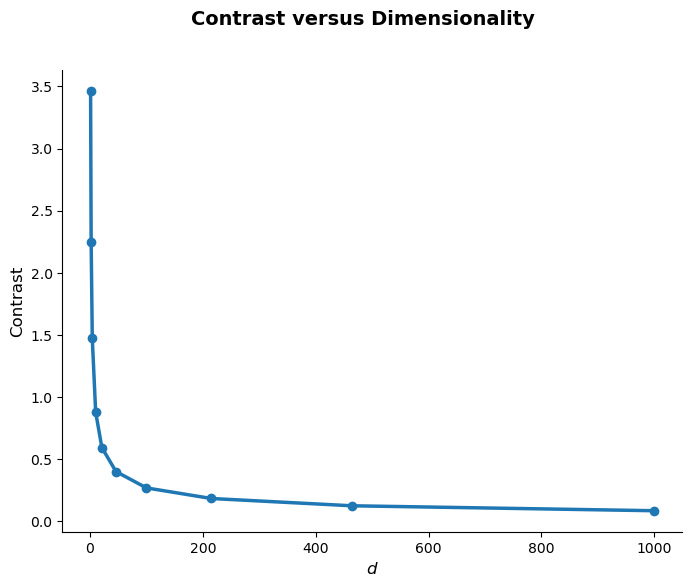

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

contrasts = []
ds = np.logspace(0, 3, 10).astype(int)
for d in ds:
    distances = [euclidean(np.zeros(d), np.random.random(d)) 
                 for _ in range(10000)]

    # Account for the band (mu + 3*sigma) - (mu - 3*sigma)
    contrasts.append(6*np.std(distances) / np.mean(distances))
ax.plot(ds, contrasts, '-o', lw=2.5)

ax.set_xlabel('$d$', fontsize=12)
ax.set_ylabel('Contrast', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
fig.suptitle("Contrast versus Dimensionality", fontsize=14, weight='bold');

Higher dimensions make the contrast of $L_p$-norms smaller making it harder to distinguish different classes. For distributions that are naturally of lower dimension, the additional dimensions is an added complication that makes it more difficult to gain insights from the data.

## 2 Dimensionality Reduction by Axis Rotation

The figures in this section are screenshots from [Powell and Lehe](https://setosa.io/ev/principal-component-analysis/). You are encouraged to visit that webpage.

Consider the dataset consisting of five points shown below. The points are two-dimensional but visually, they look like a line i.e., one dimensional. If we rotate the axis such that the $x$-axis is the red axis and the $y$-axis is the green axis, we'll get the plot on the right below. The points look like a horizontal line now.

<img src="images/line-plots.png" style="width: 50em" />

If we compare the components along the red and green axes (below right) and the original $x$ and $y$ axes (below left), we can see that the range or spread or variance along the $x$-axis is similar to the variance along the $y$-axis. On the other hand, the variance along the green axis is very small, practically negligible, compared to the variance along the red axis. Knowing the coordinate of a point along the red axis would be more informative or useful than knowing the coordinate along the green axis since the coordinates along the latter are quite similar anyway. We can, therefore, discard the green axis and just work with the red axis without losing much information. That is, we reduce the number of dimensions by retaining only high-variance axes.

<img src="images/line-pcs.png" style="width: 50em" />

Let us now look at another dataset which is shown below. This time the points are arranged in a circular or star pattern. Rotating the axes to red and green doesn't really change much the pattern (upper right). Furthermore, the variance in the coordinates along the red and green axes (lower right) are almost the same. Thus, picking just one of the axes would result in a significant loss in information similar to what would happen if we just pick the $x$ or $y$ axis.

<img src="images/star-plots.png" style="width: 50em" />
<img src="images/star-pcs.png" style="width: 50em" />

The star pattern is inherently two-dimensional unlike a linear pattern which is inherently one-dimensional so it is not surprising that we can't just reduce it to a single dimension without a significant loss of information. However, if the star pattern is embedded in more than two dimensions, say we specify three dimensions for each point coordinate, we would be able to reduce the number of dimensions into just two by following the same process: rotating the coordinate system so that it coincides with the red and green axes then discarding the other axes. This is the general idea of dimensionality reduction by axis rotation.

The process for finding the red and green axes and reducing the dimensions by rotating the coordinate system to them is part of Principal Component Analysis (PCA). The red and green axes are known as the principal components. A dataset embedded in $N$ dimensions has $N$ principal components. The principal components are orthogonal to each other and, by convention, also orthonormalized. The set of principal components is the set of axes that maximizes the explained variance. Principal components are named from 1st to $N$th ordered from the axis with the most explained variance. In the examples, PC1 is the first principal component and corresponds to the axis with the most explained variance, PC2 is the second principal component with the second most explained variance, and so on. 

The Euclidean distance or $L_2$-norm is rotation and translation invariant hence its value won't change if we perform PCA on the data.

## 3 Derivation

Consider the dataset shown below. We want to find the first principal component of the dataset. To do so, let us first pick a point $\vec x_{i,0}$. To make our life easier, we will mean-center the dataset so that the new coordinates of the point is $\vec x_i = \vec x_{i,0} - \vec{\bar x}$, where $\vec{\bar x}$ is the centroid of the dataset. 

<img src="images/pca-deriv.png" style="width: 30em" />

We now consider a unit vector $\hat w$ that passes through the origin. The projection of $\vec x_i$ on $\hat w$ is given by $(\vec x_i \cdot \hat w) \hat w$. The difference of $\vec x_i$ with its projection is known as the residual. The square of the residual is
$$
\begin{align}
\left\|\vec x_i - (\vec x_i \cdot \hat w) \hat w \right\|^2 
    &= 
    \left[\vec x_i - (\vec x_i \cdot \hat w) \hat w \right] \cdot 
    \left[\vec x_i - (\vec x_i \cdot \hat w) \hat w \right] \\
    &=
    \vec x_i \cdot \vec x_i 
    - 2(\vec x_i \cdot \hat w)(\vec x_i \cdot \hat w) 
    + (\vec x_i \cdot \hat w)^2 \hat w \cdot \hat w \\
    &=
    \left\|\vec x_i\right\|^2
    - 2(\vec x_i \cdot \hat w)^2
    + (\vec x_i \cdot \hat w)^2 \\
    &=
    \left\|\vec x_i\right\|^2
    - (\vec x_i \cdot \hat w)^2.
\end{align}
$$
We want to orient $\hat w$ such that it preserves as much information as possible. That is, we want to minimize the residual sum of squares (RSS),
$$
\begin{align}
\hat w &= \mathop{\mathrm{argmin}}_{\hat w'} RSS(\hat w') \\
    &= 
    \mathop{\mathrm{argmin}}_{\hat w'} 
    \sum_{i=1}^n \left[ \left\|\vec x_i\right\|^2 - (\vec x_i \cdot \hat w')^2 \right] \\
    &= 
    \mathop{\mathrm{argmax}}_{\hat w'} 
    \sum_{i=1}^n (\vec x_i \cdot \hat w')^2 \\
    &= 
    \mathop{\mathrm{argmax}}_{\hat w'} 
    \frac{1}{n} \sum_{i=1}^n (\vec x_i \cdot \hat w')^2 \\
    &= 
    \mathop{\mathrm{argmax}}_{\hat w'} 
    \left\{\left(\frac{1}{n} \sum_{i=1}^n \vec x_i \cdot \hat w'\right)^2 + Var[\vec x \cdot \hat w']\right\} \\
    &= 
    \mathop{\mathrm{argmax}}_{\hat w'} Var[\vec x \cdot \hat w']
\end{align}
$$
The principal component maximizes the variance of the projection of the dataset on that axis. Let $\mathbf{X}$ be a matrix with rows corresponding to each point and columns corresponding to the components of that point in the mean-centered coordinate system, and $\mathbf{w'}$ be $\hat w'$ in vector form. We can then write,
$$
\begin{align}
\hat w &= \mathop{\mathrm{argmax}}_{\hat w'} 
    \frac{1}{n} \sum_{i=1}^n (\vec x_i \cdot \hat w')^2 \\
    &=
    \mathop{\mathrm{argmax}}_{\mathbf{w'}}
    \frac{1}{n} (\mathbf{Xw'})^T (\mathbf{Xw'}) \\
    &=
    \mathop{\mathrm{argmax}}_{\mathbf{w'}}
    \frac{1}{n} (\mathbf{w'^T X^T X w'}) \\
    &=
    \mathop{\mathrm{argmax}}_{\mathbf{w'}}
    \mathbf{w'}^T \frac{\mathbf{X}^T \mathbf{X}}{n} \mathbf{w'} \\
    &=
    \mathop{\mathrm{argmax}}_{\mathbf{w'}}
    \mathbf{w'}^T \mathbf{Vw'},
\end{align}
$$
where $V$ is the covariance matrix of the dataset in the mean-centered coordinate system. We can convert the problem of solving for $\hat w$ into an optimization problem: maximize $\mathbf{w'}^T \mathbf{Vw'}$ subject to the constraint $\mathbf{w'}^T\mathbf{w'}=1$. Using the method of Lagrange,
$$
\begin{align}
u &= \mathbf{w'}^T \mathbf{Vw'} - \lambda (\mathbf{w'}^T\mathbf{w'} - 1) \\
\frac{\partial u}{\partial \mathbf{w'}} &= 2\mathbf{Vw'} - 2\lambda\mathbf{w'} \\
0 &= 2\mathbf{Vw'} - 2\lambda\mathbf{w'} \\
\mathbf{Vw'} &= \lambda\mathbf{w'}.
\end{align}
$$
The principal components are therefore the eigenvectors of the covariance matrix. The explained variance of the $i$th PC is given by $\frac{\lambda_i}{\sum_i \lambda_i}$. If we decide to keep only $k$ principal components, the cumulative variance explained is simply $\frac{\sum_{i=1}^k \lambda_i}{\sum_i \lambda_i}$.

## 4 Applied Example

Let's apply PCA with the [Cars](https://openml.org/search?type=data&status=any&sort=runs&id=455) dataset.

In [6]:
from sklearn.datasets import fetch_openml

### Data Loading

In [7]:
data = fetch_openml(data_id=455, parser='auto')

In [8]:
print(data.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Committee on Statistical Graphics of the American Statistical
Association (ASA) invites you to participate in its Second (1983)
Exposition of Statistical Graphics Technology. The purposes of the
Exposition are (l) to provide a forum in which users and providers of
statistical graphics technology can exchange information and ideas and
(2) to expose those members of the ASA community who are less familiar
with statistical graphics to its capabilities and potential benefits
to them. The Exposition wil1 be held in conjunction with the Annual
Meetings in Toronto, August 15-18, 1983 and is tentatively scheduled
for the afternoon of Wednesday, August 17.

Seven providers of statistical graphics technology participated in the
l982 Exposition. By all accounts, the Exposition was well received by
the ASA community and was a worthwhile experience for the
participants. We hope to have those seven involved again this year,

### Data Preprocessing

We remove the model year and rows with null values. We also standardize the features but you should also try to observe what happens if you run PCA without standardizing first.

In [9]:
X = (data
     .data.drop('model.year', axis=1)
     .dropna()
     .astype(float))
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [10]:
X

,mpg,cylinders,displacement,horsepower,weight,acceleration
0,-0.697747,1.482053,1.075915,0.663285,0.619748,-1.283618
1,-1.082115,1.482053,1.486832,1.572585,0.842258,-1.464852
2,-0.697747,1.482053,1.181033,1.182885,0.539692,-1.646086
3,-0.953992,1.482053,1.047246,1.182885,0.536160,-1.283618
4,-0.825870,1.482053,1.028134,0.923085,0.554997,-1.827320
...,...,...,...,...,...,...
401,0.455359,-0.862911,-0.519972,-0.479835,-0.220842,0.021267
402,2.633448,-0.862911,-0.930889,-1.363154,-0.997859,3.283479
403,1.095974,-0.862911,-0.567753,-0.531795,-0.803605,-1.428605
404,0.583482,-0.862911,-0.711097,-0.661694,-0.415097,1.108671


### PCA Computation

Let us rotate the axes and plot them along the principal components.

In [11]:
from sklearn.decomposition import PCA

In [12]:
pca = PCA()
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

To get the principal components or principal axes, we use the `.components_` attribute of the fitted `PCA` object.

In [13]:
pca.components_ # = W

array([[-0.39897309,  0.43061523,  0.44353136,  0.43412172,  0.43010308,
        -0.29192568],
       [-0.24483454,  0.14831406,  0.10849714, -0.1661584 ,  0.28609545,
         0.8926523 ],
       [ 0.85211071,  0.40032254,  0.29750498,  0.02260028,  0.12470286,
         0.09528071],
       [ 0.2208091 , -0.57631048, -0.11078321,  0.67523694,  0.34090709,
         0.18620982],
       [ 0.0710939 , -0.285904  ,  0.00559368, -0.55858804,  0.72661186,
        -0.27053257],
       [-0.03119071, -0.46737615,  0.83108055, -0.12431178, -0.27097508,
         0.03179437]])

While the eigenvalues or $\lambda$ can be obtained by using the `.explained_variance_` attribute

In [14]:
pca.explained_variance_ # lambda

array([4.78826616, 0.72863111, 0.25846732, 0.12517701, 0.0631764 ,
       0.036282  ])

In [15]:
variance_explained = pca.explained_variance_ / pca.explained_variance_.sum()
variance_explained

array([0.79804436, 0.12143852, 0.04307789, 0.02086284, 0.0105294 ,
       0.006047  ])

In [16]:
pca.explained_variance_ratio_

array([0.79804436, 0.12143852, 0.04307789, 0.02086284, 0.0105294 ,
       0.006047  ])

The first principal component already explains 79.8% of the observed variance. We perform dimensionality reduction by selecting $q < p$ principal components from the original $p$ dimensions. In practice, we look at the total variance explained by the $q$ principal components and select the value of $q$ based on the desired total variance explained.

### Choosing the Number of PCs

To determine the number of principal components to retain, we can plot the cumulative variance explained versus the number of components then deciding how many dimensions according to a certain cumulative variance explained target tolerance.

In [17]:
from utils import plot_cum_exp_var

Let us arbitrarily set a total variance explained threshold of 90%. This corresponds to two PCs. 

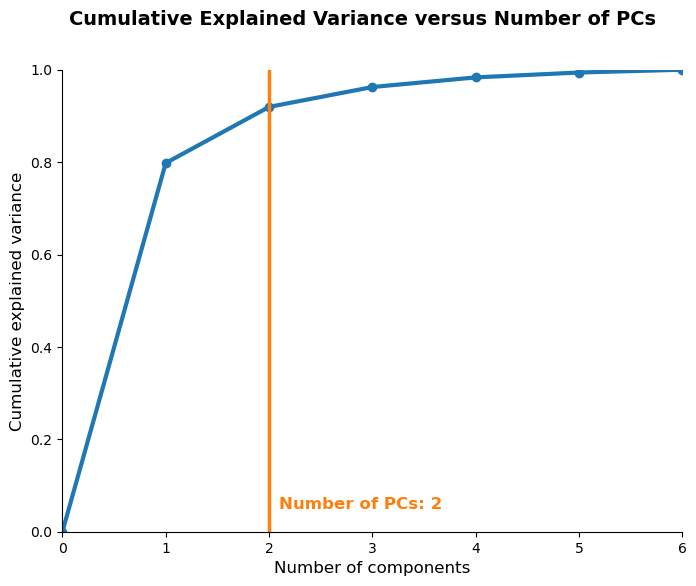

In [18]:
plot_cum_exp_var(pca.explained_variance_ratio_, tol=0.90);

### Transforming the Original Feature Vectors

To transform the original feature vectors, we first get the eigenvectors from our PCA computation.

In [19]:
W = pca.components_

In [20]:
W.shape

(6, 6)

In [21]:
W = pd.DataFrame(W, columns=X.columns,
                 index=[f'PC {i + 1}' for i in range(X.shape[1])])
W

,mpg,cylinders,displacement,horsepower,weight,acceleration
PC 1,-0.398973,0.430615,0.443531,0.434122,0.430103,-0.291926
PC 2,-0.244835,0.148314,0.108497,-0.166158,0.286095,0.892652
PC 3,0.852111,0.400323,0.297505,0.022600,0.124703,0.095281
PC 4,0.220809,-0.576310,-0.110783,0.675237,0.340907,0.186210
PC 5,0.071094,-0.285904,0.005594,-0.558588,0.726612,-0.270533
PC 6,-0.031191,-0.467376,0.831081,-0.124312,-0.270975,0.031794


The transformed feature vectors can be obtained as denoted by the following equation

$$
\vec{x}'_i = (\vec{x} \cdot \vec{w}_i) \vec{w}_i
$$

Or in matrix form, this can be written as:

$$
X' = WX
$$

In code this can be executed using the following operation:

In [22]:
(W @ X.T).T # same as pca.transform(X)

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6
0,2.323002,-0.571352,0.288803,-0.707256,-0.040238,-0.067944
1,3.201965,-0.681870,0.114558,-0.181550,-0.362482,0.106457
2,2.666576,-0.992744,0.287299,-0.462835,-0.290003,-0.035005
3,2.602139,-0.621975,0.063243,-0.438304,-0.409595,-0.125719
4,2.596582,-1.092197,0.111405,-0.678144,-0.094696,-0.135694
...,...,...,...,...,...,...
401,-1.093383,-0.260354,-0.148478,0.260128,0.377984,0.077130
402,-3.814625,1.998282,1.779211,0.532707,-0.423178,0.091768
403,-1.220113,-1.874707,0.171190,-0.096859,0.421080,0.135715
404,-1.709210,0.632857,-0.020889,0.323056,0.052283,0.024113


In [23]:
X_transformed = pd.DataFrame((W @ X.T).T)
X_transformed

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6
0,2.323002,-0.571352,0.288803,-0.707256,-0.040238,-0.067944
1,3.201965,-0.681870,0.114558,-0.181550,-0.362482,0.106457
2,2.666576,-0.992744,0.287299,-0.462835,-0.290003,-0.035005
3,2.602139,-0.621975,0.063243,-0.438304,-0.409595,-0.125719
4,2.596582,-1.092197,0.111405,-0.678144,-0.094696,-0.135694
...,...,...,...,...,...,...
401,-1.093383,-0.260354,-0.148478,0.260128,0.377984,0.077130
402,-3.814625,1.998282,1.779211,0.532707,-0.423178,0.091768
403,-1.220113,-1.874707,0.171190,-0.096859,0.421080,0.135715
404,-1.709210,0.632857,-0.020889,0.323056,0.052283,0.024113


### Interpreting the PCs

In [24]:
from utils import plot_principal_components

To ease interpretation, let us plot the original coordinates into the new PCs.

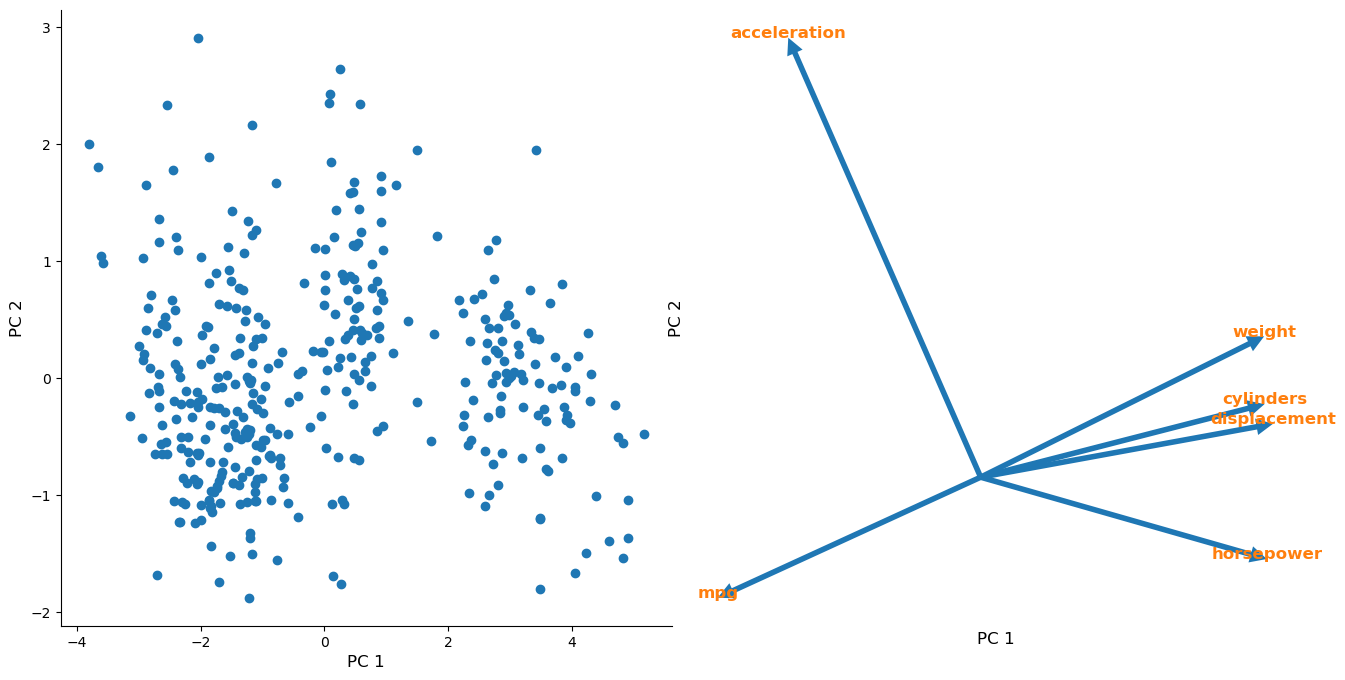

In [25]:
plot_principal_components(X_transformed, W, 'PC 1', 'PC 2');

Here are some of the things that you can look when interpreting the resulting scatter plot:

* **Coordinates**: What do the directions of each PC mean? Use the general direction of the transformed dimensions as a guide.
* **Correlations**: Which groups of transformed dimensions point toward the same direction? Which are opposite to each other? These suggest correlation or anticorrelation.
* **Clusters**: Which points clump together?
* **Funnels**: Are there points that are wide on one side and narrow on the other? This suggest dependence of principal components.
* **Voids**: Are there unusually unpopulated areas? This suggests certain combinations of values are unlikely to occur.

<img src="images/banner-down.png" style="width: 100%;">